In [1]:
import math
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from graphcast.model_utils import stacked_to_dataset
from graphcast.losses import normalized_latitude_weights
from graphufs.stacked_utils import get_channel_index
from graphufs.datasets import Dataset
from prototypes.ocn_only.emulator import OcnEvaluator, OcnTrainer

In [2]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

In [3]:
def calculate_the_metric(model_pred, ref_truth, metric="SQE", clima=None):
    """
    Calculates the given metric against the reference truth.
    The metric parameter can take the following values: "SQE"/"ABS"/"ACC"
    """
    # Create a land/sea mask based on the salinity field at the first time step
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)
    
    error_metric_vars = {}
    
    # Pre-calculate reference anomaly
    if metric.lower() == "acc": 
        reference_anomaly_all = ref_truth - clima

    for var in model_pred.data_vars:
        # Determine the correct mask to use for this variable (with or without depth)
        current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        
        # Compute error and apply mask
        error = (model_pred[var] - ref_truth[var]) * current_mask

        # ---- calculate the appropriate metric using the above error statistics ----
        # SQE (squared error)
        if metric.lower() == "sqe":
            error_metric_vars[var] = error**2
        
        # ABS (absolute error)
        elif metric.lower() == "abs":
            error_metric_vars[var] = abs(error)
        
        else:
            raise KeyError(f"{metric} is not recognized. Only SQE and ABS are supported")
        
    return error_metric_vars

## Config and Computation 

In [4]:
# ---- Config ----
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
PLOT_METRIC = "RMSE"

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-MLoss",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
]

In [5]:
# ---- The Main Computation Block ----
# Initialize dictionaries to store all results
all_error = {}
    
# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"Processing Model: {model_name}")
        
    all_error[model_name] = {}
    
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
        
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")
            
        # Construct the path to the truth data
        if model_config["type"] in ["persistence", "climatology"]:
            # Logic to find the corresponding replay file for baselines
            run = "R5" if model_config['timestep'] == "24h" else "R4"
            expt = "T1M" if model_config['timestep'] == "24h" else "T3M"
            duration = "240h"
            location = os.path.join(SCRATCH_DIR, model_config["model_type"], run, f"inference_{expt}/validation/")
            fname = f"{location}/replay.{duration}.zarr"
        else:
            infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
            location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
            fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"

        ref_truth = xr.open_zarr(fname)
            
        # Calculate the desired metric for this model against this truth
        if PLOT_METRIC.lower() == "rmse":
            metric = "SQE"
        elif PLOT_METRIC.lower() == "mae":
            metric = "ABS"
        else:
            raise KeyError(f"The desired metric is not recognized. Only RMSE and MAE are supported")

        # Compute the error metric
        error = calculate_the_metric(model_pred, ref_truth, metric=metric)
            
        # Store results
        all_error[model_name][truth_name] = error

print("\n--- Metric calculation complete!! ---")

Processing Model: Emulator-24h-MSE
Comparing against truth: Replay ...
Processing Model: Emulator-24h-MLoss
Comparing against truth: Replay ...

--- Metric calculation complete!! ---


## Plotting 

In [6]:
def calculate_rmse(sqerr_da, apply_weighting=False, depth_level=0, 
                   dims_to_skip_for_avg=["lead_time", "time"]):
    """
    Calculates the Root Mean Squared Error from a squared error DataArray.
    
    This function correctly preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in sqerr_da.dims:
        sqerr_da = sqerr_da.isel(z_l=depth_level)
    
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(sqerr_da)
        sqerr_da = sqerr_da * weights.astype(sqerr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    # The 'time' dimension (or 'init_time') holds the samples for the CI.
    dims_to_avg = [dim for dim in sqerr_da.dims if dim not in dims_to_skip_for_avg]
    
    # Calculate the mean over spatial dimensions and take the square root
    rmse_da = np.sqrt(sqerr_da.mean(dim=dims_to_avg))
    
    return rmse_da

In [7]:
def calculate_mae(abserr_da, apply_weighting=False, depth_level=0, 
                  dims_to_skip_for_avg=["lead_time", "time"]):
    """
    Calculates the Mean Absolute Error from an absolute error DataArray.
    
    This function preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in abserr_da.dims:
        abserr_da = abserr_da.isel(z_l=depth_level)
    
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(abserr_da)
        abserr_da = abserr_da * weights.astype(abserr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    dims_to_avg = [dim for dim in abserr_da.dims if dim not in dims_to_skip_for_avg]
    
    # Calculate the mean over spatial dimensions
    mae_da = abserr_da.mean(dim=dims_to_avg)
    
    return mae_da

In [8]:
def plot_spatial_error(ax,
                       da_2d: xr.DataArray,
                       cmap: str = 'cividis', # A great default for sequential data
                       vmin: float = None,
                       vmax: float = None,
                       add_colorbar: bool = False,
                       cbar_label: str = "",
                      ):
    """
    Plots a 2D spatial error map with manuscript-quality features.
    The input DataArray must be 2D (lat, lon).
    """
    # cbar kwargs
    cbar_kwargs={}
    if add_colorbar:
        cbar_kwargs['orientation'] = 'horizontal'
        cbar_kwargs['pad'] = 0.1
        cbar_kwargs['aspect'] = 20
        cbar_kwargs['shrink'] = 0.65
        cbar_kwargs['label'] = cbar_label
        
    # Plot the data
    p = da_2d.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=add_colorbar,
        cbar_kwargs=cbar_kwargs,
        add_labels=False,
    )

    # Add geographical features for context
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k', facecolor='lightgray')
    ax.coastlines(resolution='50m', color='black', linewidth=0.7)
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    return p

## Plotting params

In [9]:
# ---- Units ----
units = {}
units["SSH"] = "m"
units["so"] = "psu"
units["temp"] = "degC"
units["uo"] = "m/s"
units["vo"] = "m/s"

In [10]:
# ---- Error Bounds ----
error_bounds = {}

# RMSE
error_bounds["RMSE"] = {}
error_bounds["RMSE"]["SSH"] = {"vmin":0, "vmax":0.05}  # 0-15 cm
error_bounds["RMSE"]["so"] = {"vmin":0, "vmax":0.2}   # 0-0.4 psu
error_bounds["RMSE"]["temp"] = {"vmin":0, "vmax":0.5} # 0-0.5 degC
error_bounds["RMSE"]["uo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
error_bounds["RMSE"]["vo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
###################
# MAE
error_bounds["MAE"] = {}
error_bounds["MAE"]["SSH"] = {"vmin":0, "vmax":0.025}  # 0-16 cm
error_bounds["MAE"]["so"] = {"vmin":0, "vmax":0.07}   # 0-0.4 psu
error_bounds["MAE"]["temp"] = {"vmin":0, "vmax":0.25} # 0-0.5 degC
error_bounds["MAE"]["uo"] = {"vmin":0, "vmax":0.07}  # 0-0.25 m/s
error_bounds["MAE"]["vo"] = {"vmin":0, "vmax":0.07}  # 0-0.25 m/s
###################
# ACC
error_bounds["ACC"] = {}
error_bounds["ACC"]["SSH"] = {"vmin":0.7, "vmax":1}  # 0-16 cm
error_bounds["ACC"]["so"] = {"vmin":0.85, "vmax":1}   # 0-0.4 psu
error_bounds["ACC"]["temp"] = {"vmin":0.9, "vmax":1} # 0-0.5 degC
error_bounds["ACC"]["uo"] = {"vmin":0.4, "vmax":1}  # 0-0.25 m/s
error_bounds["ACC"]["vo"] = {"vmin":0.2, "vmax":1}  # 0-0.25 m/s

In [37]:
# ---- Plotting Settings ----
var_list = ["temp", "so"] 
print_name = ["Temp", "Salinity"]
iz_l = 4

SAVE_PLOT = True # remember to change the file name if needed
APPLY_LATITUDE_WEIGHTING = False
PLOT_FORECAST_DAY = 10

# --- Main Logic ---
N_MODELS = len(MODELS_CONFIG)
N_MODELS_REL = N_MODELS - 1 # removing one for the baseline
N_VARS = len(var_list)
model_name_baseline = MODELS_CONFIG[0]["name"]

# Total rows needed for both sections
TOTAL_ROWS = N_MODELS + N_MODELS_REL

## Normalized RMSE Diff = (RMSE_model - RMSE_baseline)*100 / RMSE_baseline.

In [38]:
# ---- Global Settings ----
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': 'DejaVu Sans', 'font.size': 14})

# --- Helper Function for Metric Calculation ---
def get_metric_map(config, var_name, truth, iz_l, PLOT_METRIC, APPLY_LATITUDE_WEIGHTING):
    """Calculates RMSE or MAE map for a given model and variable."""
    # all_error contains the squared error (for RMSE) or absolute error (for MAE)
    err = all_error[config["name"]][truth][var_name] 
    dims_to_skip = ["lat", "lon", "lead_time"] # Skip these dimensions to get the spatial map
    
    if PLOT_METRIC == "RMSE":
        return calculate_rmse(err, APPLY_LATITUDE_WEIGHTING, iz_l, dims_to_skip)
    elif PLOT_METRIC == "MAE":
        return calculate_mae(err, APPLY_LATITUDE_WEIGHTING, iz_l, dims_to_skip)
    return None

--- Processing Truth: Replay ---


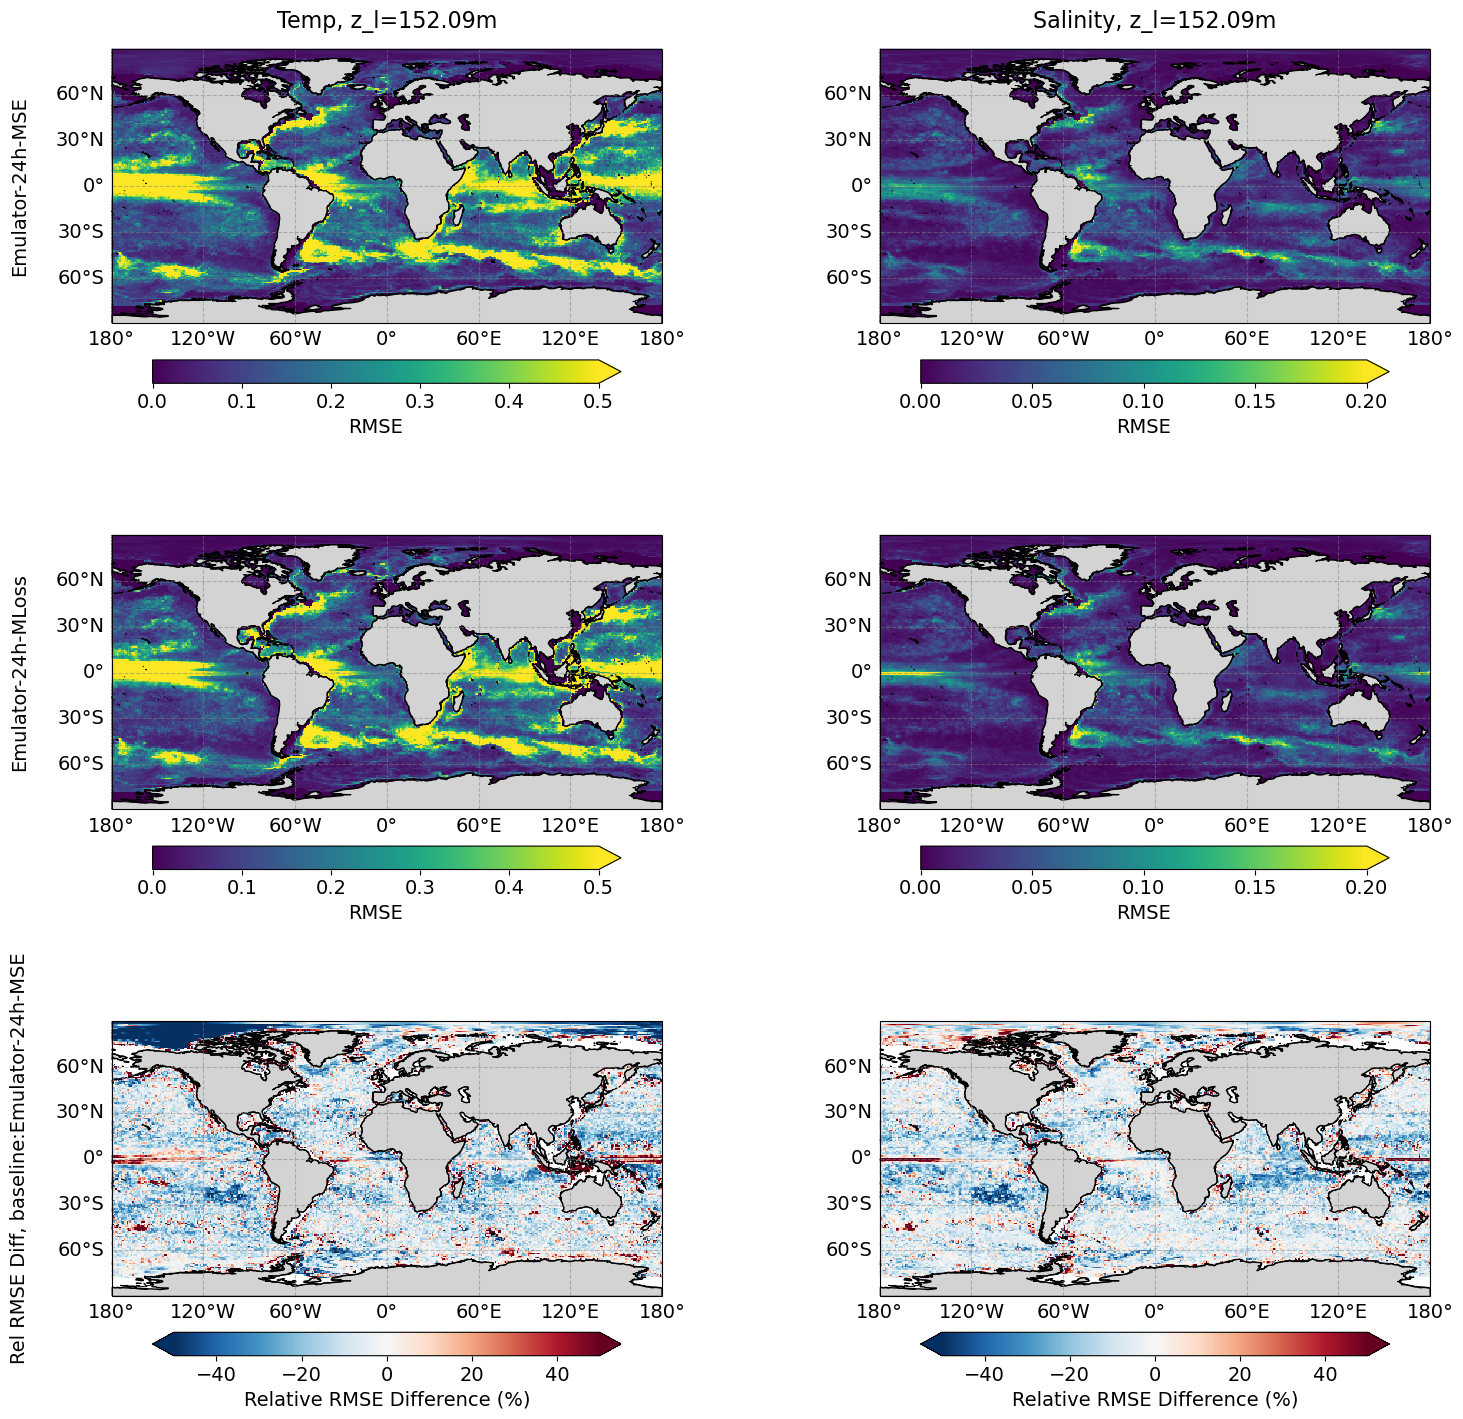

In [39]:
for truth in TRUTHS:
    print(f"--- Processing Truth: {truth} ---")

    # --- 1. Pre-calculate all necessary data ---
    all_metric_maps = {} 
    baseline_error_maps = {}

    for config in MODELS_CONFIG:
        model_name = config["name"]
        all_metric_maps[model_name] = {}
        
        # Calculate time step indices once per configuration
        timestep_hours = int(config["timestep"][:-1])
        steps_per_day = 24 // timestep_hours
        forecast_day_idx = PLOT_FORECAST_DAY * steps_per_day
        
        for var_name in var_list:
            metric_map = get_metric_map(config, var_name, truth, iz_l, PLOT_METRIC, APPLY_LATITUDE_WEIGHTING)
            data_for_day = metric_map.isel(lead_time=forecast_day_idx - 1)
            all_metric_maps[model_name][var_name] = data_for_day
            
            if model_name == model_name_baseline:
                 baseline_error_maps[var_name] = data_for_day

    # --- 2. Setup the Figure ---
    # Create the grid: Total_Rows (N_MODELS + N_MODELS_REL) x N_VARS
    fig, ax_array = plt.subplots(TOTAL_ROWS, N_VARS, 
                                 figsize=(8 * N_VARS, 5 * TOTAL_ROWS),
                                 subplot_kw={"projection":ccrs.PlateCarree()})

    # Ensure ax_array is always 2D even for single rows/columns
    if TOTAL_ROWS == 1 and N_VARS == 1:
        ax_array = np.array([[ax_array]])
    elif TOTAL_ROWS == 1:
        ax_array = ax_array[np.newaxis, :]
    elif N_VARS == 1:
        ax_array = ax_array[:, np.newaxis]

    # --- 3. Plot Error Maps (Rows 0 to N_MODELS - 1) ---
    for i, config in enumerate(MODELS_CONFIG): 
        model_name = config["name"]
        
        for j, var_name in enumerate(var_list):
            ax = ax_array[i, j]
            data_to_plot = all_metric_maps[model_name][var_name]
            
            # Plotting
            p = plot_spatial_error(
                ax, data_to_plot,
                vmin=error_bounds[PLOT_METRIC][var_name]["vmin"],
                vmax=error_bounds[PLOT_METRIC][var_name]["vmax"],
                cmap='viridis', add_colorbar=True,
                cbar_label=PLOT_METRIC,
            )

            # --- Set Titles and Labels ---
            if i == 0:
                ax.set_title(f"{print_name[j]}, z_l={data_to_plot.z_l.values:.2f}m", fontsize=16, pad=15)
            if j == 0:
                ax.text(-0.15, 0.5, f"{model_name}", transform=ax.transAxes,
                        ha='right', va='center', rotation='vertical', fontsize=14)

    # --- 4. Plot Relative Difference Maps (Rows N_MODELS to TOTAL_ROWS - 1) ---
    # Calculate the row offset: The starting row index for relative plots
    row_offset = N_MODELS 

    for i, config in enumerate(MODELS_CONFIG[1:]): # Start from the second model (index 1)
        model_name = config["name"]
        
        # Current row index in the figure grid: row_offset + i
        fig_row_idx = row_offset + i 
        
        for j, var_name in enumerate(var_list):
            ax = ax_array[fig_row_idx, j]
            
            # --- relative difference calculation ---
            current_metric_day = all_metric_maps[model_name][var_name]
            numerator = current_metric_day - baseline_error_maps[var_name]
            denominator = baseline_error_maps[var_name]
            relative_diff = xr.where(
                denominator != 0,
                (numerator / denominator) * 100,
                np.nan
            )
                
            vmax_rel = 50 # Hardcoded relative max/min
            
            # Plotting
            p = plot_spatial_error(
                ax, relative_diff,
                vmin=-vmax_rel, vmax=vmax_rel,
                cmap='RdBu_r', add_colorbar=True,
                cbar_label=f"Relative {PLOT_METRIC} Difference (%)",
            )
            
            # --- Set Titles and Labels ---
            if j == 0:
                # Label for the relative difference row
                ax.text(-0.15, 0.5, f"Rel RMSE Diff, baseline:{model_name_baseline}", 
                        transform=ax.transAxes,
                        ha='right', va='center', rotation='vertical', fontsize=14)

    # --- Finalize Figure ---
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.96]) # Adjust rect for suptitle

    # Save the figure
    if SAVE_PLOT:
        figname = f"{PLOT_FORECAST_DAY}-day_forecast_spatial_RMSE_{print_name[0]}_{print_name[1]}_z_l={data_to_plot.z_l.values:.2f}m.png"
        if APPLY_LATITUDE_WEIGHTING:
            figname = f"LW-{figname}"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()